# State

In [54]:
from typing_extensions import TypedDict
from typing import Literal

class TypedDictState(TypedDict):
    name:str
    game:Literal["handball","rugby"]

# Nodes

In [55]:
def play_game(state:TypedDictState):
    
    print("Play game node has been called")
    return {"name":state["name"] + " wants to play "}

def handball(state:TypedDictState):
    
    print("Handball node has been called")
    return {"name":state["name"] + "handball","game":"handball"}

def rugby(state:TypedDictState):

    print("Rugby node has been called")
    return {"name":state["name"] + "rugby","game":"rugby"}

# Conditional edges

In [56]:
import random

def decide_play(state:TypedDictState)->Literal["handball","rugby"]:
    
    if random.random() < 0.5:
        return "handball"
    else:
        return "rugby"

# Graph

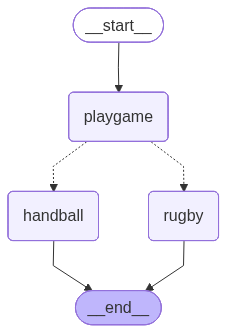

In [57]:
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END

# Build graph
builder=StateGraph(TypedDictState)

# Adding the nodes
builder.add_node("playgame",play_game)
builder.add_node("handball",handball)
builder.add_node("rugby",rugby)

# Schedule the flow of the graph
builder.add_edge(START,"playgame")
builder.add_conditional_edges("playgame",decide_play)
builder.add_edge("handball",END)
builder.add_edge("rugby",END)

# Compile the graph
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

# Graph invocation

In [58]:
graph.invoke({"name":"Nicolas"})

Play game node has been called
Handball node has been called


{'name': 'Nicolas wants to play handball', 'game': 'handball'}

# DataClasses

In [59]:
from dataclasses import dataclass

@dataclass
class DataClassState:
    name:str
    game:Literal["handball","rugby"]

In [60]:
def play_game(state:DataClassState):
    
    print("Play game node has been called")
    return {"name":state.name + " wants to play "}

def handball(state:DataClassState):
    
    print("Handball node has been called")
    return {"name":state.name + "handball","game":"handball"}

def rugby(state:DataClassState):

    print("Rugby node has been called")
    return {"name":state.name + "rugby","game":"rugby"}

In [61]:
import random

def decide_play(state:DataClassState)->Literal["handball","rugby"]:
    
    if random.random() < 0.5:
        return "handball"
    else:
        return "rugby"

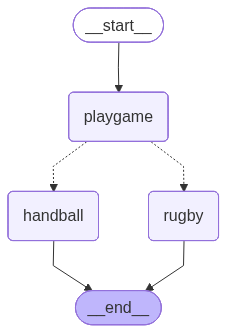

In [62]:
# Build graph
builder=StateGraph(TypedDictState)

# Adding the nodes
builder.add_node("playgame",play_game)
builder.add_node("handball",handball)
builder.add_node("rugby",rugby)

# Schedule the flow of the graph
builder.add_edge(START,"playgame")
builder.add_conditional_edges("playgame",decide_play)
builder.add_edge("handball",END)
builder.add_edge("rugby",END)

# Compile the graph
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [63]:
graph.invoke(DataClassState(name="Nicolas",game="handball"))

Play game node has been called
Handball node has been called


{'name': 'Nicolas wants to play handball', 'game': 'handball'}